# Step 1:Import Libraries





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Step 2:Load Dataset

In [ ]:
df = pd.read_csv('cars_ds_final.csv')

df.head()

,Unnamed: 0,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
0,0,Tata,Nano Genx,Xt,"Rs. 2,92,667",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Tata,Nano Genx,Xe,"Rs. 2,36,447",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Tata,Nano Genx,Emax Xm,"Rs. 2,96,661",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Tata,Nano Genx,Xta,"Rs. 3,34,768",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Tata,Nano Genx,Xm,"Rs. 2,72,223",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Step 3:Dataset Understanding



* **Shape**



In [ ]:
df.shape

(1276, 141)





* **Columns**



In [ ]:
df.columns

Index(['Unnamed: 0', 'Make', 'Model', 'Variant', 'Ex-Showroom_Price',
       'Displacement', 'Cylinders', 'Valves_Per_Cylinder', 'Drivetrain',
       'Cylinder_Configuration',
       ...
       'Leather_Wrapped_Steering', 'Automatic_Headlamps', 'Engine_Type',
       'ASR_/_Traction_Control', 'Cruise_Control', 'USB_Ports',
       'Heads-Up_Display', 'Welcome_Lights', 'Battery', 'Electric_Range'],
      dtype='object', length=141)



* **Data Types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1276 entries, 0 to 1275
Columns: 141 entries, Unnamed: 0 to Electric_Range
dtypes: float64(6), int64(1), object(134)
memory usage: 1.4+ MB




* **Statistical Summary**



In [ ]:
df.describe()

,Unnamed: 0,Cylinders,Valves_Per_Cylinder,Doors,Seating_Capacity,Number_of_Airbags,USB_Ports
count,1276.000000,1210.000000,1174.000000,1272.000000,1270.000000,1141.000000,29.000000
mean,637.500000,4.380992,3.977853,4.550314,5.270079,3.787029,1.793103
std,368.493781,1.660957,0.833763,0.747816,1.145231,2.522399,0.773642
min,0.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000
25%,318.750000,4.000000,4.000000,4.000000,5.000000,2.000000,1.000000
50%,637.500000,4.000000,4.000000,5.000000,5.000000,2.000000,2.000000
75%,956.250000,4.000000,4.000000,5.000000,5.000000,6.000000,2.000000
max,1275.000000,16.000000,16.000000,5.000000,16.000000,14.000000,3.000000


# Step 4: Missing Value Analysis



* **Count Missing Values**



In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
Other_Specs,1266
Recommended_Tyre_Pressure,1266
Battery,1263
Electric_Range,1259
ARAI_Certified_Mileage_for_CNG,1249
...,...
Seating_Capacity,6
Doors,4
Torque,2
Type,1




* **Visualize Missing Values**



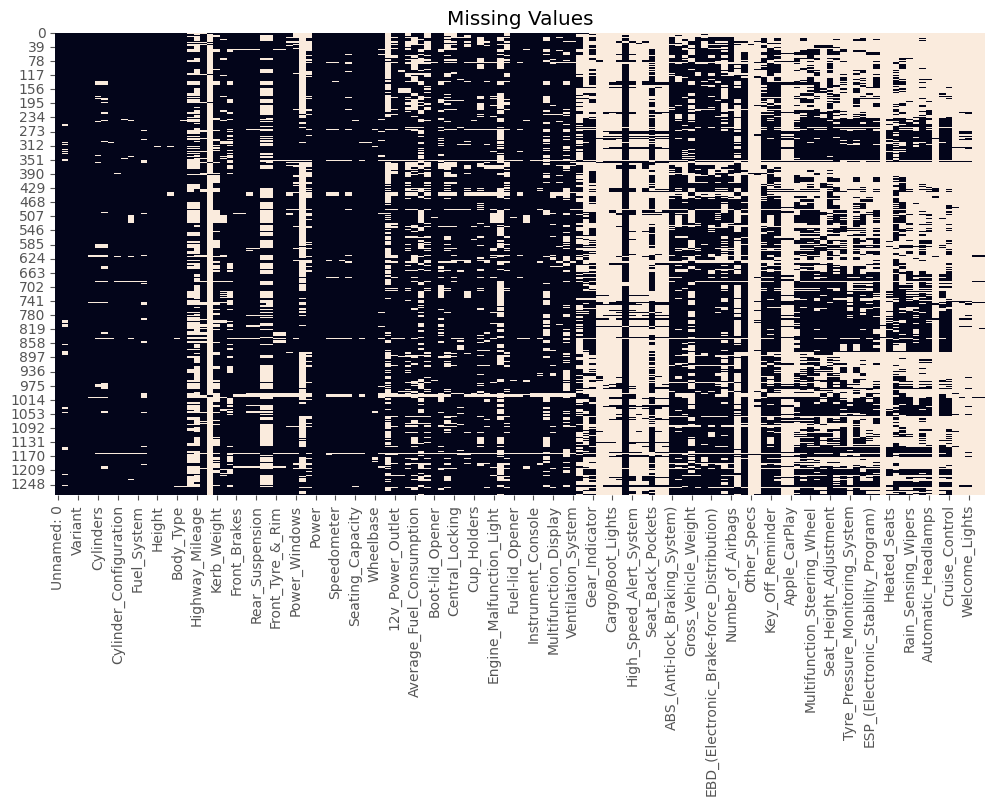

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")
plt.show()

# Step 5: Data Cleaning



* **Remove Unwanted Column**



In [ ]:
df.drop("Unnamed: 0", axis=1, inplace=True)



* **Convert Price Column**



In [ ]:
df["Ex-Showroom_Price"] = (
    df["Ex-Showroom_Price"]
    .str.replace("Rs.","")
    .str.replace(",","")
)

df["Ex-Showroom_Price"] = pd.to_numeric(
    df["Ex-Showroom_Price"],
    errors="coerce"
)



* **Convert Mileage**



In [ ]:
df["ARAI_Certified_Mileage"] = (
    df["ARAI_Certified_Mileage"]
    .astype(str)
    .str.extract('(\d+\.?\d*)')
)

df["ARAI_Certified_Mileage"] = pd.to_numeric(
    df["ARAI_Certified_Mileage"],
    errors="coerce"
)

# Step 6: Exploratory Data Analysis (EDA)



* **Top Car Brands**



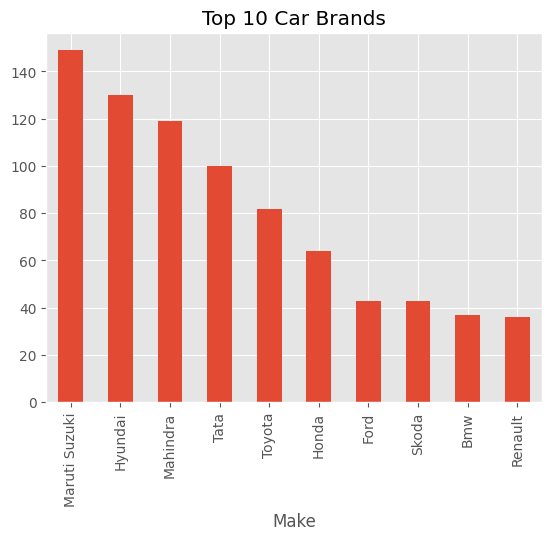

In [ ]:
top_brands = df["Make"].value_counts().head(10)

top_brands.plot(kind="bar")
plt.title("Top 10 Car Brands")
plt.show()



* **Fuel Type Distribution**



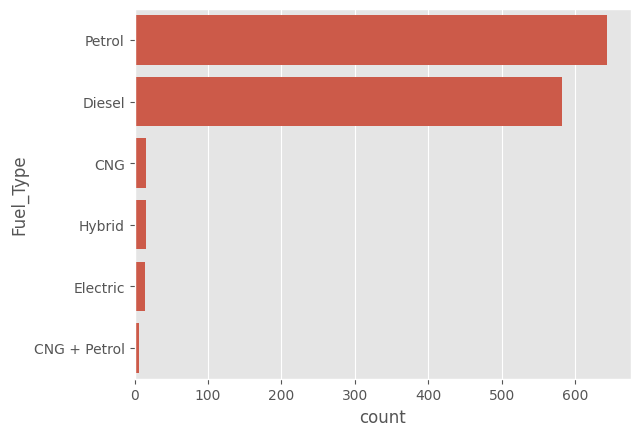

In [ ]:
sns.countplot(
    y=df["Fuel_Type"],
    order=df["Fuel_Type"].value_counts().index
)

plt.show()



* **Body Type Analysis**



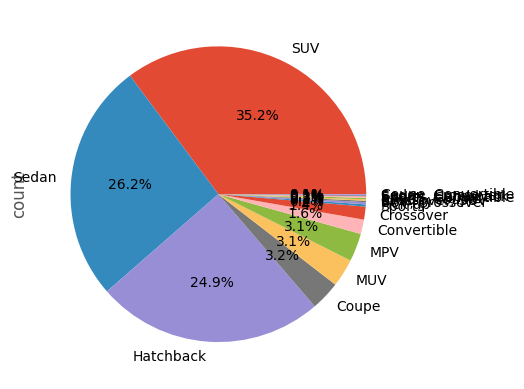

In [ ]:
df["Body_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()



* **Price Distribution**



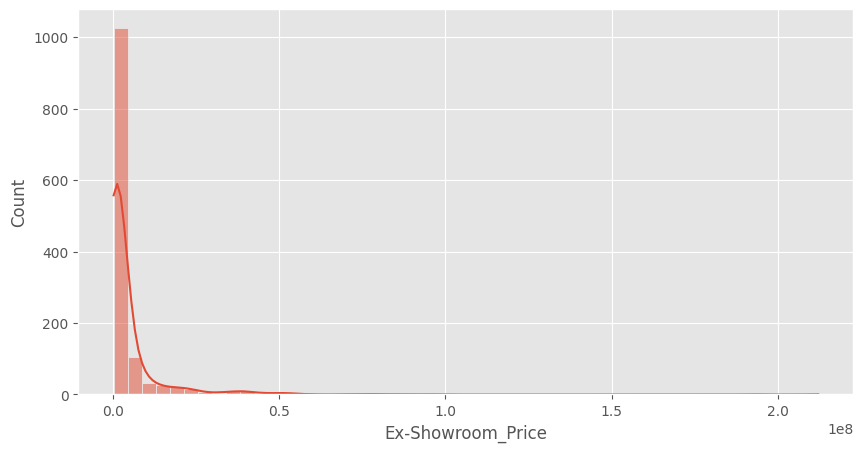

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Ex-Showroom_Price"],
    bins=50,
    kde=True
)

plt.show()



* **Most Expensive Cars**



In [ ]:
df[
    ["Make","Model","Ex-Showroom_Price"]
].sort_values(
    by="Ex-Showroom_Price",
    ascending=False
).head(10)

,Make,Model,Ex-Showroom_Price
356,Bugatti,Chiron,212155397
355,Bugatti,Chiron,192142937
1219,NaN,Rolls-Royce Phantom,95000000
880,NaN,Rolls-Royce Drophead Coupe,83755383
354,NaN,Rolls-Royce Phantom Coupe,77312661
1220,NaN,Rolls-Royce Phantom,75400000
353,NaN,Rolls-Royce Cullinan,69500000
879,NaN,Rolls-Royce Dawn,59216193
350,NaN,Rolls-Royce Ghost Series Ii,53247201
877,Lamborghini,Aventador,53210327




* **Cheapest Cars**



In [ ]:
df[
    ["Make","Model","Ex-Showroom_Price"]
].sort_values(
    by="Ex-Showroom_Price"
).head(10)

,Make,Model,Ex-Showroom_Price
1,Tata,Nano Genx,236447
357,Bajaj,Qute (Re60),263000
4,Tata,Nano Genx,272223
6,Datsun,Redi-Go,279650
881,Maruti Suzuki,Omni,282778
358,Bajaj,Qute (Re60),283000
13,Renault,Kwid,283290
882,Maruti Suzuki,Omni,284485
0,Tata,Nano Genx,292667
359,Maruti Suzuki,Alto,294800


# Step 7: Mileage Analysis



* **Top Mileage Cars**



In [ ]:
df[
    ["Make","Model","ARAI_Certified_Mileage"]
].sort_values(
    by="ARAI_Certified_Mileage",
    ascending=False
).head(10)

,Make,Model,ARAI_Certified_Mileage
1036,NaN,Mercedes-Benz C-Class,1449.0
794,NaN,Mercedes-Benz E-Class,142.0
800,NaN,Mercedes-Benz E-Class,142.0
799,NaN,Mercedes-Benz E-Class,142.0
795,NaN,Mercedes-Benz E-Class,142.0
357,Bajaj,Qute (Re60),35.0
165,Maruti Suzuki,Dzire,28.4
164,Maruti Suzuki,Dzire,28.4
118,Maruti Suzuki,Dzire Tour,28.4
157,Maruti Suzuki,Dzire,28.4




* **Mileage by Fuel Type**



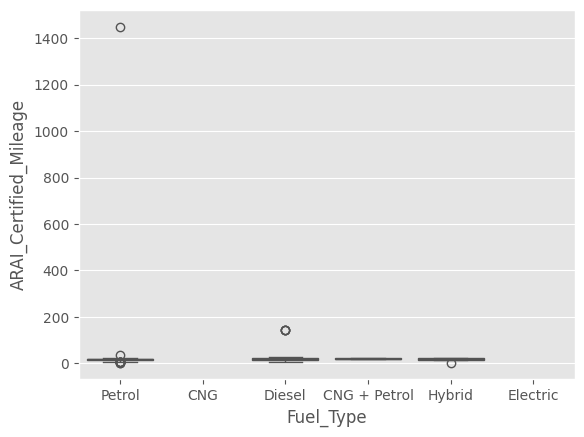

In [ ]:
sns.boxplot(
    x="Fuel_Type",
    y="ARAI_Certified_Mileage",
    data=df
)

plt.show()

# Step 8: Engine Performance Analysis



* **Extract Power Value**



In [ ]:
df["Power_num"] = (
    df["Power"]
    .astype(str)
    .str.extract('(\d+\.?\d*)')
)

df["Power_num"] = pd.to_numeric(
    df["Power_num"],
    errors="coerce"
)



* **Top Powerful Cars**



In [ ]:
df[
    ["Make","Model","Power_num"]
].sort_values(
    by="Power_num",
    ascending=False
).head(10)

,Make,Model,Power_num
356,Bugatti,Chiron,1600.0
355,Bugatti,Chiron,1479.0
1058,Ferrari,812 Superfast,789.0
878,Lamborghini,Aventador,740.0
876,Lamborghini,Aventador,700.0
877,Lamborghini,Aventador,700.0
875,Ferrari,Gtc4 Lusso,681.0
873,Ferrari,488 Gtb,670.0
872,Ferrari,488 Gtb,670.0
1172,Ferrari,458 Spider,669.0


# Step 9: Seating Capacity Analysis

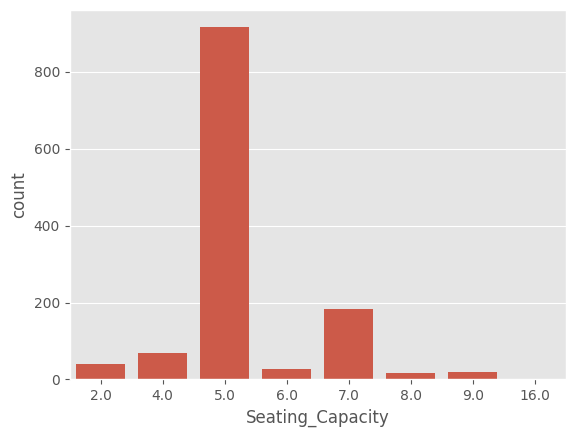

In [ ]:
sns.countplot(
    x=df["Seating_Capacity"]
)

plt.show()

# Step 10: Correlation Analysis




* **Select Numerical Columns**





In [ ]:
num_df = df.select_dtypes(
    include=['int64','float64']
)



* **Correlation Matrix**



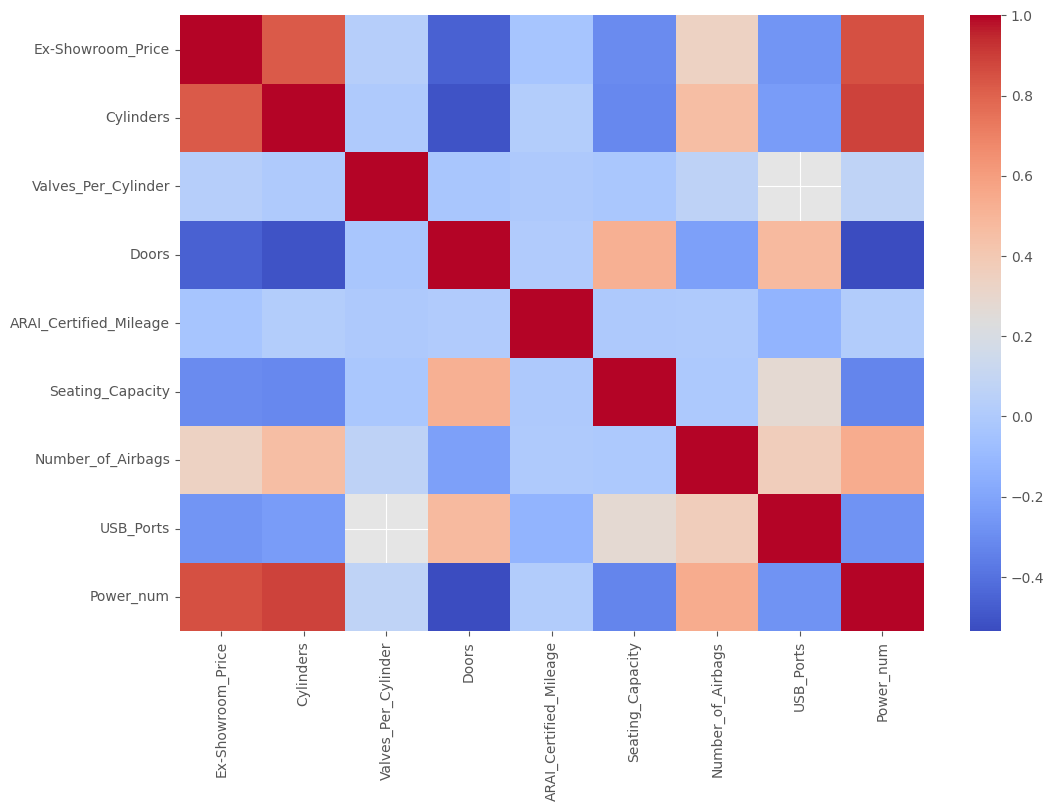

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    num_df.corr(),
    cmap="coolwarm"
)

plt.show()

# Step 11: Advanced Analysis



* **Price vs Mileage**



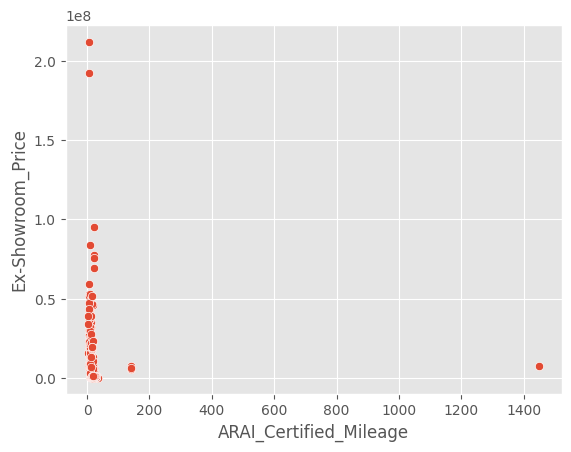

In [ ]:
sns.scatterplot(
    x="ARAI_Certified_Mileage",
    y="Ex-Showroom_Price",
    data=df
)

plt.show()



* **Price vs Power**



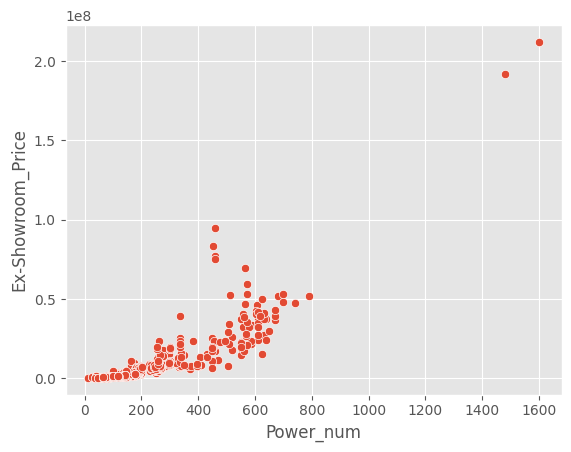

In [ ]:
sns.scatterplot(
    x="Power_num",
    y="Ex-Showroom_Price",
    data=df
)

plt.show()

# Step 12: Feature Analysis



* **Airbags Distribution**



In [ ]:
df["Airbags"].value_counts()

,count
Airbags,
"Driver frontal airbag, Front passenger frontal airbag",578
Driver frontal airbag,61
"Front passenger frontal airbag, Driver frontal airbag",39
"Curtain airbags, Driver frontal airbag, Front passenger frontal airbag, Front passenger side airbag, Drive side airbag",36
"Drive side airbag, Driver frontal airbag, Front passenger frontal airbag, Front passenger side airbag",20
...,...
"Drive side airbag, Front passenger curtain airbag, Rear passenger curtain airbags, Driver frontal airbag, Front passenger side airbag",1
"Drive side airbag, Front passenger curtain airbag, Driver frontal airbag, Rear passenger curtain airbags, Front passenger side airbag",1
"Drive side airbag, Driver frontal airbag, Front passenger curtain airbag, Front passenger side airbag, Rear passenger curtain airbags",1




* **ABS Availability**



In [ ]:
df["ABS_(Anti-lock_Braking_System)"].value_counts()

,count
ABS_(Anti-lock_Braking_System),
Yes,1144




* **Android Auto Support**



In [ ]:
df["Android_Auto"].value_counts()

,count
Android_Auto,
Yes,173


# Step 13: Save Visualizations

In [ ]:
plt.savefig(
    "brand_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>